In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [6]:
# ======================================================
# 1. LOAD DỮ LIỆU & CHUẨN BỊ
# ======================================================
# Đường dẫn file data đã làm sạch (nhớ kiểm tra lại đường dẫn máy bạn)
path_data = '../../data/processed/training_data_final.csv'

if not os.path.exists(path_data):
    print("❌ Lỗi: Không tìm thấy file dữ liệu!")
else:
    print("✅ Đã tìm thấy file dữ liệu.")

df = pd.read_csv(path_data, parse_dates=['Datetime'], index_col='Datetime')

# Chỉ lấy cột 'Gold' cho mô hình đơn biến
data = df[['Gold']].values

✅ Đã tìm thấy file dữ liệu.


In [7]:
# ======================================================
# 2. CHUẨN HÓA (SCALING)
# ======================================================
# LSTM rất nhạy cảm với biên độ, bắt buộc phải đưa về [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [8]:
# ======================================================
# 3. TẠO CỬA SỔ TRƯỢT (SLIDING WINDOW)
# ======================================================
def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        # Lấy 60 giá trước đó làm Input (X)
        X.append(dataset[i:(i + time_step), 0])
        # Lấy giá ngay sau đó làm Output (y)
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

# Cấu hình: Nhìn lại 60 phút quá khứ để đoán phút tiếp theo
time_step = 60 
X, y = create_dataset(scaled_data, time_step)

# Reshape dữ liệu về dạng 3D [Samples, Time Steps, Features] để LSTM hiểu
# Features = 1 (vì chỉ có Gold)
X = X.reshape(X.shape[0], X.shape[1], 1)

print(f"Kích thước dữ liệu đầu vào (X): {X.shape}")

Kích thước dữ liệu đầu vào (X): (94972, 60, 1)


In [9]:
# ======================================================
# 4. CHIA TRAIN / TEST
# ======================================================
# Time-series KHÔNG ĐƯỢC random shuffle. Cắt theo thời gian.
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [10]:
# ======================================================
# 5. XÂY DỰNG MÔ HÌNH LSTM
# ======================================================
model = Sequential()

# Layer 1: LSTM (return_sequences=True để nối tiếp layer sau)
model.add(LSTM(units=50, return_sequences=True, input_shape=(time_step, 1)))
model.add(Dropout(0.2)) # Tránh học tủ (Overfitting)

# Layer 2: LSTM
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Layer Output: 1 nơ-ron (Giá Gold dự đoán)
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

# ======================================================
# 6. HUẤN LUYỆN (TRAINING)
# ======================================================
# Dùng EarlyStopping: Nếu sau 5 vòng (patience=5) mà loss ko giảm thì dừng luôn cho nhanh
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("🚀 Bắt đầu huấn luyện...")
history = model.fit(
    X_train, y_train,
    epochs=50,           # Số vòng lặp tối đa
    batch_size=64,       # Học 64 mẫu cùng lúc (tăng tốc độ)
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)
print("✅ Huấn luyện hoàn tất!")

c:\Users\minam\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🚀 Bắt đầu huấn luyện...
Epoch 1/50
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 77s 60ms/step - loss: 0.0068 - val_loss: 2.1573e-05
Epoch 2/50
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 64s 54ms/step - loss: 0.0026 - val_loss: 2.0514e-05
Epoch 3/50
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 63s 53ms/step - loss: 0.0018 - val_loss: 2.6573e-05
Epoch 4/50
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 65s 55ms/step - loss: 0.0012 - val_loss: 1.2353e-04
Epoch 5/50
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 65s 55ms/step - loss: 9.5459e-04 - val_loss: 1.4137e-04
Epoch 6/50
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 63s 53ms/step - loss: 8.8433e-04 - val_loss: 5.1711e-05
Epoch 7/50
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 66s 55ms/step - loss: 8.5474e-04 - val_loss: 1.5812e-04
✅ Huấn luyện hoàn tất!


In [13]:
predictions = model.predict(X_test)
# 1. Load lại file dữ liệu GỐC
path_raw = '../../data/raw/data_price_realtime.csv' 
df_real_usd = pd.read_csv(path_raw)

# 2. Tạo một Scaler mới
real_price_scaler = MinMaxScaler(feature_range=(0, 1))
real_price_scaler.fit(df_real_usd[['Gold']]) 

# 3. Đảo ngược chuẩn hóa (FIX LỖI TẠI ĐÂY)
# Thêm .reshape(-1, 1) vào cả 2 biến để đảm bảo nó là mảng 2 chiều
pred_usd = real_price_scaler.inverse_transform(predictions.reshape(-1, 1))
actual_usd = real_price_scaler.inverse_transform(y_test.reshape(-1, 1)) # <--- Dòng này đã được sửa

# 4. Lưu lại kết quả chuẩn
test_dates = df.index[-len(actual_usd):]

result_df = pd.DataFrame({
    'Datetime': test_dates,
    'Actual': actual_usd.flatten(),     # Duỗi ra lại thành 1 chiều để lưu vào Excel
    'Predicted': pred_usd.flatten()
})

# Tạo folder và lưu file
import os
save_path = '../../results/predictions/LSTM.csv'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
result_df.to_csv(save_path, index=False)

print(f"\n✅ Đã lưu file kết quả (USD thật) tại: {save_path}")
print(result_df.head())

594/594 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step

✅ Đã lưu file kết quả (USD thật) tại: ../../results/predictions/LSTM.csv
             Datetime       Actual    Predicted
0 2025-12-07 05:07:00  4184.851748  4185.067871
1 2025-12-07 05:07:10  4184.851748  4185.067871
2 2025-12-07 05:07:20  4184.851748  4185.067871
3 2025-12-07 05:07:30  4184.851748  4185.067871
4 2025-12-07 05:07:40  4184.851748  4185.067871


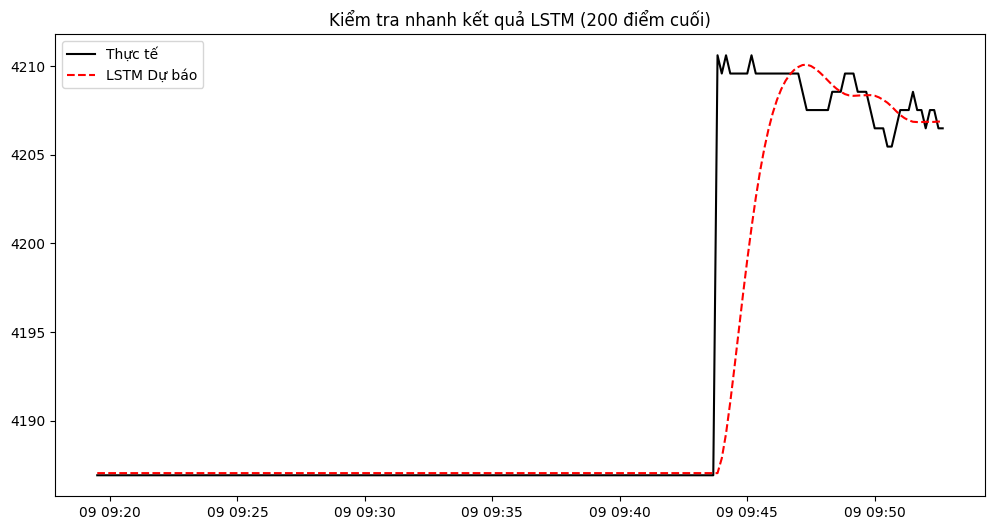

In [14]:
# ======================================================
# 9. VẼ BIỂU ĐỒ KIỂM TRA NHANH
# ======================================================
plt.figure(figsize=(12, 6))
# Chỉ vẽ 200 điểm cuối
plt.plot(result_df['Datetime'][-200:], result_df['Actual'][-200:], label='Thực tế', color='black')
plt.plot(result_df['Datetime'][-200:], result_df['Predicted'][-200:], label='LSTM Dự báo', color='red', linestyle='--')
plt.title('Kiểm tra nhanh kết quả LSTM (200 điểm cuối)')
plt.legend()
plt.show()